In [1]:
# ==============================================================================
# CELL 1: SETUP AND IMPORTS
# ==============================================================================

# Standard Library
import os
import shutil
import random
import itertools
import time
import copy # Added for deepcopy in BYOL_CLIP

# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F # Added for F.normalize in byol_loss
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset # Dataset added for BYOLDataset
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

# Hugging Face Transformers
from transformers import CLIPModel, AutoFeatureExtractor # Added CLIPModel

# Scikit-Learn (Machine Learning)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split

# Extra ML/Stats Tools
from scipy.special import softmax
from sklearn.manifold import TSNE

# Progress Bar
from tqdm import tqdm

# Kaggle
import kagglehub

# PIL for image handling
from PIL import Image

print("All libraries imported successfully.")

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

All libraries imported successfully.
Using device: cuda


In [2]:
import os

dataset_path = "/kaggle/input/ai-medleafx"



In [3]:
dataset_path = "/kaggle/input/ai-medleafx"
print("Verified path to dataset files:", dataset_path)

# Assuming the structure is dataset_path -> 'Resized Image' -> Plant Type -> Disease/Health Status -> Images
resized_image_base_path = os.path.join(dataset_path, 'Resized Image')

all_class_dirs = []
class_counts = {}

print("\nExploring dataset structure and counting images:")

try:
    # List plant type directories within 'Resized Image'
    plant_type_dirs = [d for d in os.listdir(resized_image_base_path) if os.path.isdir(os.path.join(resized_image_base_path, d))]
    print(f"\nFound {len(plant_type_dirs)} plant types:", plant_type_dirs)

    if not plant_type_dirs:
        print("No plant type directories found within 'Resized Image'. Cannot proceed with expected structure.")
    else:
        # Iterate through each plant type directory
        for plant_type_dir in plant_type_dirs:
            plant_type_path = os.path.join(resized_image_base_path, plant_type_dir)

            # List disease/health status directories within each plant type
            status_dirs = [d for d in os.listdir(plant_type_path) if os.path.isdir(os.path.join(plant_type_path, d))]
            print(f"\nExploring '{plant_type_dir}': Found {len(status_dirs)} status categories:", status_dirs)

            if not status_dirs:
                print(f"No status directories found within '{plant_type_dir}'.")
            else:
                # Iterate through each status directory (these are the actual classes)
                for status_dir in status_dirs:
                    class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
                    class_path = os.path.join(plant_type_path, status_dir)
                    all_class_dirs.append(class_name)

                    # Count image files in the class directory
                    image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))]
                    class_counts[class_name] = len(image_files_in_class)
                    print(f"- {class_name}: {class_counts[class_name]} images")

        # Determine the total number of classes
        num_classes = len(all_class_dirs)
        print(f"\nTotal number of classes: {num_classes}")

        # Display class distribution summary
        print("\nClass distribution:")
        for class_name, count in class_counts.items():
            print(f"- {class_name}: {count}")

        # Calculate total number of images
        total_images = sum(class_counts.values())
        print(f"\nTotal number of images: {total_images}")

except FileNotFoundError:
    print(f"Error: The directory '{resized_image_base_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


print("\nDataset exploration and counting complete.")

Verified path to dataset files: /kaggle/input/ai-medleafx

Exploring dataset structure and counting images:

Found 4 plant types: ['Sojina', 'Neem', 'Camphor', 'HariTaki']

Exploring 'Sojina': Found 3 status categories: ['Yellow Leaf', 'Healthy Leaf', 'Bacterial Spot']
- Sojina_Yellow Leaf: 814 images
- Sojina_Healthy Leaf: 860 images
- Sojina_Bacterial Spot: 804 images

Exploring 'Neem': Found 4 status categories: ['Powdery Mildew', 'Yellow Leaf', 'Healthy Leaf', 'Shot Hole Leaf']
- Neem_Powdery Mildew: 854 images
- Neem_Yellow Leaf: 854 images
- Neem_Healthy Leaf: 1021 images
- Neem_Shot Hole Leaf: 834 images

Exploring 'Camphor': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- Camphor_Healthy Leaf: 800 images
- Camphor_Shot Hole: 795 images
- Camphor_Bacterial Spot: 801 images

Exploring 'HariTaki': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- HariTaki_Healthy Leaf: 816 images
- HariTaki_Shot Hole: 802 images
- HariTaki_Ba

In [4]:
# ==============================================================================
# CELL 3: DATA SPLITTING
# ==============================================================================

# Define paths
original_base_dir = resized_image_base_path # Corrected path to point to the existing 'Augmented DataSet'
new_base_dir = '/content/data'

# Collect image paths and labels
data = []
# Iterate through each plant type directory
for plant_type_dir in os.listdir(original_base_dir):
    plant_type_path = os.path.join(original_base_dir, plant_type_dir)
    if not os.path.isdir(plant_type_path): # Ensure it's a directory
        continue

    # List disease/health status directories within each plant type
    for status_dir in os.listdir(plant_type_path):
        class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
        class_path = os.path.join(plant_type_path, status_dir)
        if not os.path.isdir(class_path): # Ensure it's a directory
            continue

        # Count image files in the class directory
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.JPG')):
                data.append({'path': os.path.join(class_path, fname), 'label': class_name})

df = pd.DataFrame(data)

# Split dataset: 80% train, 10% val, 10% test
train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)
# Output summary
total = len(df)
print(f"\n Dataset Split Summary:")
print(f"- Total images: {total}")
print(f"- Training set : {len(train):5d} images ({len(train)/total:.1%})")
print(f"- Validation set: {len(val):5d} images ({len(val)/total:.1%})")
print(f"- Test set     : {len(test):5d} images ({len(test)/total:.1%})\n")

# Copy files
for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    print(f" Copying {split} files...")
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))
    print(f" {split.capitalize()} files copied: {len(split_df)}")

print("\n All files have been split and copied successfully.")


 Dataset Split Summary:
- Total images: 10858
- Training set :  8794 images (81.0%)
- Validation set:   978 images (9.0%)
- Test set     :  1086 images (10.0%)

 Copying train files...
 Train files copied: 8794
 Copying val files...
 Val files copied: 978
 Copying test files...
 Test files copied: 1086

 All files have been split and copied successfully.


In [5]:
class BYOL_CLIP(nn.Module):
    def __init__(self, projection_dim=256, tau=0.99):
        super().__init__()

        # Load CLIP ViT backbone
        clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.backbone = clip.vision_model
        self.embed_dim = 768

        # Projection head
        self.projector = nn.Sequential(
            nn.Linear(self.embed_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Linear(2048, projection_dim)
        )

        # Prediction head (only for online network)
        self.predictor = nn.Sequential(
            nn.Linear(projection_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Linear(2048, projection_dim)
        )

        # Target network (EMA)
        self.target_backbone = copy.deepcopy(self.backbone)
        self.target_projector = copy.deepcopy(self.projector)

        for param in self.target_backbone.parameters():
            param.requires_grad = False
        for param in self.target_projector.parameters():
            param.requires_grad = False

        self.tau = tau

    def forward(self, x1, x2):
        # Online network
        z1 = self.projector(self.backbone(x1).pooler_output)
        z2 = self.projector(self.backbone(x2).pooler_output)
        p1 = self.predictor(z1)
        p2 = self.predictor(z2)

        # Target network
        with torch.no_grad():
            t1 = self.target_projector(self.target_backbone(x1).pooler_output)
            t2 = self.target_projector(self.target_backbone(x2).pooler_output)

        return p1, p2, t1, t2

    @torch.no_grad()
    def update_target(self):
        for online, target in zip(self.backbone.parameters(), self.target_backbone.parameters()):
            target.data = self.tau * target.data + (1 - self.tau) * online.data
        for online, target in zip(self.projector.parameters(), self.target_projector.parameters()):
            target.data = self.tau * target.data + (1 - self.tau) * online.data

    def get_features(self, x):
        """
        Extract features from the backbone's pooled output (before the projection head).
        """
        return self.backbone(x).pooler_output


def byol_loss(p, t):
    p = F.normalize(p, dim=-1)
    t = F.normalize(t, dim=-1)
    return 2 - 2 * (p * t).sum(dim=-1).mean()

print("✓ Model defined")

✓ Model defined


In [6]:
# ===================================================================
# CELL 4: Data Augmentation
# ===================================================================

class TwoViewsTransform:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)

print("✓ Augmentation defined")


✓ Augmentation defined


In [7]:
# ===================================================================
# CELL 5: Load CIFAR-10 Dataset
# ===================================================================

# For BYOL training (with augmentation)
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True,
                                  transform=TwoViewsTransform())
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=2, pin_memory=True)

# For evaluation (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_eval = datasets.CIFAR10(root='./data', train=True, transform=eval_transform)
test_eval = datasets.CIFAR10(root='./data', train=False, transform=eval_transform)

train_eval_loader = DataLoader(train_eval, batch_size=256, shuffle=False, num_workers=2)
test_eval_loader = DataLoader(test_eval, batch_size=256, shuffle=False, num_workers=2)

print(f"✓ Dataset loaded: {len(train_dataset)} training images")


100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


✓ Dataset loaded: 50000 training images


In [8]:
# ===================================================================
# CELL 6: Train BYOL (Self-Supervised)
# ===================================================================

model = BYOL_CLIP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6)

epochs = 50
print(f"\nTraining BYOL for {epochs} epochs...")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for (x1, x2), _ in train_loader:
        x1, x2 = x1.to(device), x2.to(device)

        p1, p2, t1, t2 = model(x1, x2)
        loss = byol_loss(p1, t2) + byol_loss(p2, t1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.update_target()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("✓ BYOL training complete!")

# ===================================================================
# CELL 7: Extract Features
# ===================================================================

@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    features, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        feat = model.backbone(imgs).pooler_output
        features.append(feat.cpu())
        labels.append(lbls)
    return torch.cat(features), torch.cat(labels)

print("Extracting features...")
X_train, y_train = extract_features(model, train_eval_loader)
X_test, y_test = extract_features(model, test_eval_loader)
print(f"✓ Features extracted: {X_train.shape}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]


Training BYOL for 50 epochs...
Epoch 1/50 - Loss: 1.2492
Epoch 2/50 - Loss: 0.9635
Epoch 3/50 - Loss: 0.8822
Epoch 4/50 - Loss: 0.8253
Epoch 5/50 - Loss: 0.8044
Epoch 6/50 - Loss: 0.7918
Epoch 7/50 - Loss: 0.7999
Epoch 8/50 - Loss: 0.7989
Epoch 9/50 - Loss: 0.7895
Epoch 10/50 - Loss: 0.7740
Epoch 11/50 - Loss: 0.7642
Epoch 12/50 - Loss: 0.7517
Epoch 13/50 - Loss: 0.7505
Epoch 14/50 - Loss: 0.7362
Epoch 15/50 - Loss: 0.7483
Epoch 16/50 - Loss: 0.7475
Epoch 17/50 - Loss: 0.7279
Epoch 18/50 - Loss: 0.7096
Epoch 19/50 - Loss: 0.7220
Epoch 20/50 - Loss: 0.7248
Epoch 21/50 - Loss: 0.7142
Epoch 22/50 - Loss: 0.7081
Epoch 23/50 - Loss: 0.7001
Epoch 24/50 - Loss: 0.6901
Epoch 25/50 - Loss: 0.6830
Epoch 26/50 - Loss: 0.6797
Epoch 27/50 - Loss: 0.6735
Epoch 28/50 - Loss: 0.6644
Epoch 29/50 - Loss: 0.6664
Epoch 30/50 - Loss: 0.6556
Epoch 31/50 - Loss: 0.6562
Epoch 32/50 - Loss: 0.6515
Epoch 33/50 - Loss: 0.6480
Epoch 34/50 - Loss: 0.6481
Epoch 35/50 - Loss: 0.6488
Epoch 36/50 - Loss: 0.6441
Epoch

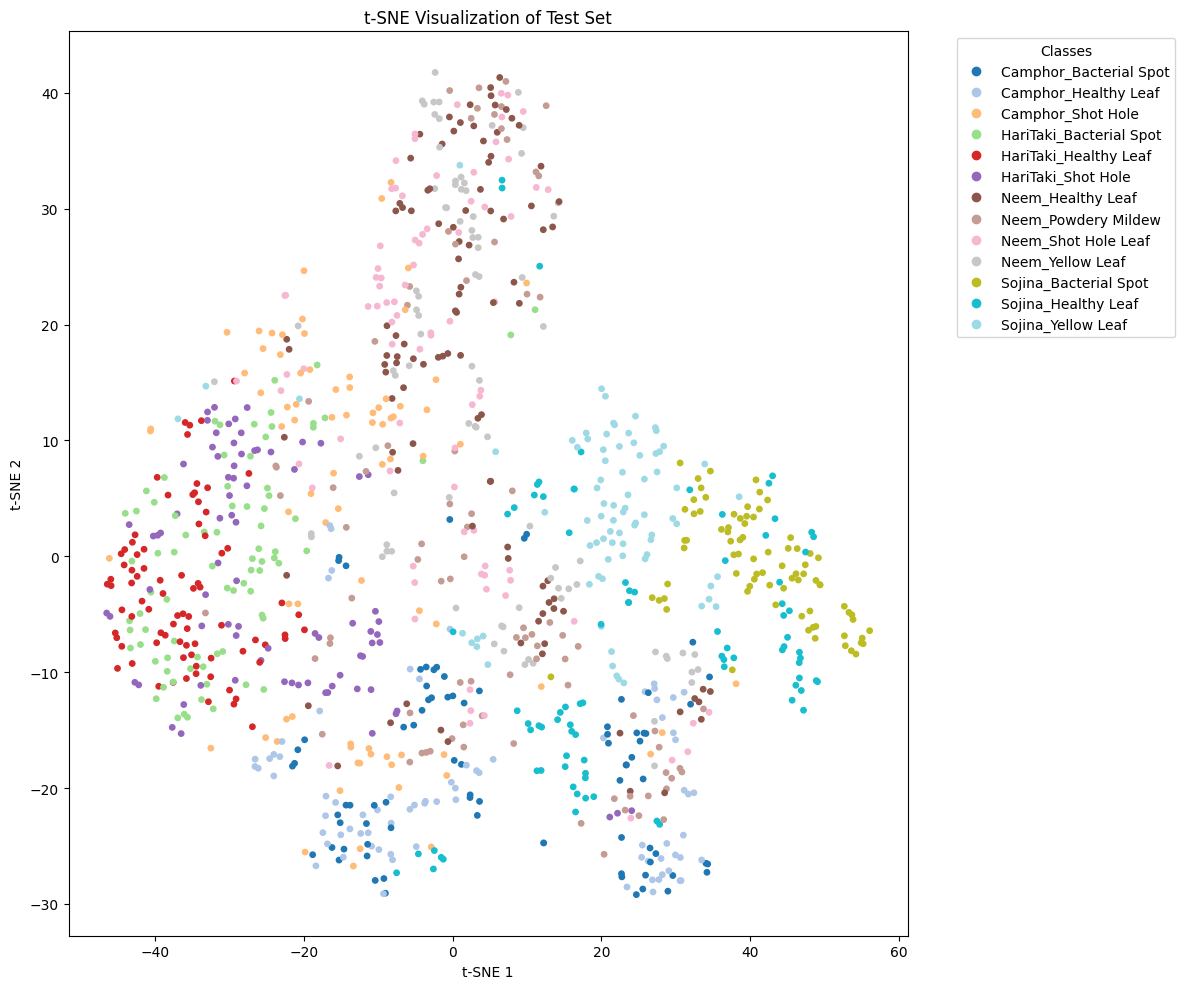

In [9]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get class mappings for the downstream task (from the ai-medleafx dataset)
all_labels = sorted(list(df['label'].unique()))
label_to_idx = {label: i for i, label in enumerate(all_labels)}
num_classes_plant = len(all_labels)

# Define custom dataset for the plant dataset
class ImageFolderDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = label_map if label_map is not None else label_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        label_name = self.dataframe.iloc[idx]['label']
        label_id = self.label_map[label_name]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label_id

# Define transformations for feature extraction
# This should be the same as eval_transform from CELL 5
extract_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# =========================================
#  Create test dataset
# =========================================
test_dataset_plant = ImageFolderDataset(
    test,                      # your test dataset (DataFrame/list of paths & labels)
    transform=extract_transform,
    label_map=label_to_idx
)

# =========================================
#  Create DataLoader for test dataset
# =========================================
test_loader = DataLoader(
    test_dataset_plant,
    batch_size=64,             # same batch size as train/val
    shuffle=False,             # do NOT shuffle test set
    num_workers=2,
    pin_memory=True
)

# =========================================
# 1️⃣ Feature Extraction Function
# =========================================
def extract_features(model, loader, device='cuda'):
    model.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats = model.get_features(images)  # Or model.forward_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

# =========================================
# 2️⃣ Extract Features from Test Loader
# =========================================
# This uses the correct model and the correct test_loader_plant data structure:
X_test_plant, y_test_plant = extract_features(model, test_loader, device='cuda') 

# Adjust the subsequent steps to use the new variable names
# 3️⃣ t-SNE Dimensionality Reduction
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
# Change X_test to X_test_plant
X_test_tsne = tsne.fit_transform(X_test_plant) 

# 4️⃣ Map integer labels to class names
idx_to_class = {v: k for k, v in label_to_idx.items()} # Use label_to_idx from the plant data
# Change y_test to y_test_plant
y_test_names = [idx_to_class[i] for i in y_test_plant] 

# 5️⃣ Plot t-SNE with class names
plt.figure(figsize=(12, 10))
# Change y_test to y_test_plant
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test_plant, cmap='tab20', s=15)

# Create legend with actual class names
handles, _ = scatter.legend_elements()
# Change y_test to y_test_plant
unique_labels = np.unique(y_test_plant)

plt.legend(handles, [idx_to_class[i] for i in unique_labels], title="Classes",
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t-SNE Visualization of Test Set")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [10]:


# Create datasets and dataloaders for the actual plant dataset splits
# 'train' and 'val' DataFrames are from cell 4918d0ee
train_dataset_plant = ImageFolderDataset(train, transform=extract_transform, label_map=label_to_idx)
val_dataset_plant = ImageFolderDataset(val, transform=extract_transform, label_map=label_to_idx)

train_loader_plant = DataLoader(train_dataset_plant, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
val_loader_plant = DataLoader(val_dataset_plant, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------
# 1️⃣ Feature Extraction
# -----------------------------
def extract_features_for_mlp(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            # Correctly get features from the BYOL_CLIP model's backbone
            feats = model.backbone(images).pooler_output  # (batch, feature_dim)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels

# Extract train/validation features for the plant dataset
train_X, train_y = extract_features_for_mlp(model, train_loader_plant, device)
val_X, val_y = extract_features_for_mlp(model, val_loader_plant, device)




# -----------------------------
# 2️⃣ Standardize Features
# -----------------------------
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
val_X = scaler.transform(val_X)

# -----------------------------
# 3️⃣ Dimensionality Reduction (Optional but recommended)
# -----------------------------
pca = PCA(n_components=512)  # reduce to 512 features
train_X = pca.fit_transform(train_X)
val_X = pca.transform(val_X)

# -----------------------------
# 4️⃣ Train MLP Classifier
# -----------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=1000,
    random_state=42,
    verbose=True
)

mlp.fit(train_X, train_y)

# -----------------------------
# 5️⃣ Evaluate Accuracy
# -----------------------------
preds = mlp.predict(val_X)
acc = accuracy_score(val_y, preds)
print(f"\n🔍 Optimized MLP Accuracy: {acc * 100:.2f}%")

Extracting features: 100%|██████████| 16/16 [00:04<00:00,  3.55it/s]


Iteration 1, loss = 1.65431260
Iteration 2, loss = 0.86412833
Iteration 3, loss = 0.62757850
Iteration 4, loss = 0.51528689
Iteration 5, loss = 0.44633580
Iteration 6, loss = 0.38943376
Iteration 7, loss = 0.35209732
Iteration 8, loss = 0.31494249
Iteration 9, loss = 0.28530098
Iteration 10, loss = 0.25381591
Iteration 11, loss = 0.23317324
Iteration 12, loss = 0.21281541
Iteration 13, loss = 0.19251031
Iteration 14, loss = 0.17215517
Iteration 15, loss = 0.15892299
Iteration 16, loss = 0.14503348
Iteration 17, loss = 0.12773373
Iteration 18, loss = 0.11530455
Iteration 19, loss = 0.10483967
Iteration 20, loss = 0.09643044
Iteration 21, loss = 0.08679208
Iteration 22, loss = 0.07876085
Iteration 23, loss = 0.07165032
Iteration 24, loss = 0.06493630
Iteration 25, loss = 0.05821147
Iteration 26, loss = 0.05263862
Iteration 27, loss = 0.04762801
Iteration 28, loss = 0.04589124
Iteration 29, loss = 0.04054172
Iteration 30, loss = 0.03674810
Iteration 31, loss = 0.03384963
Iteration 32, los

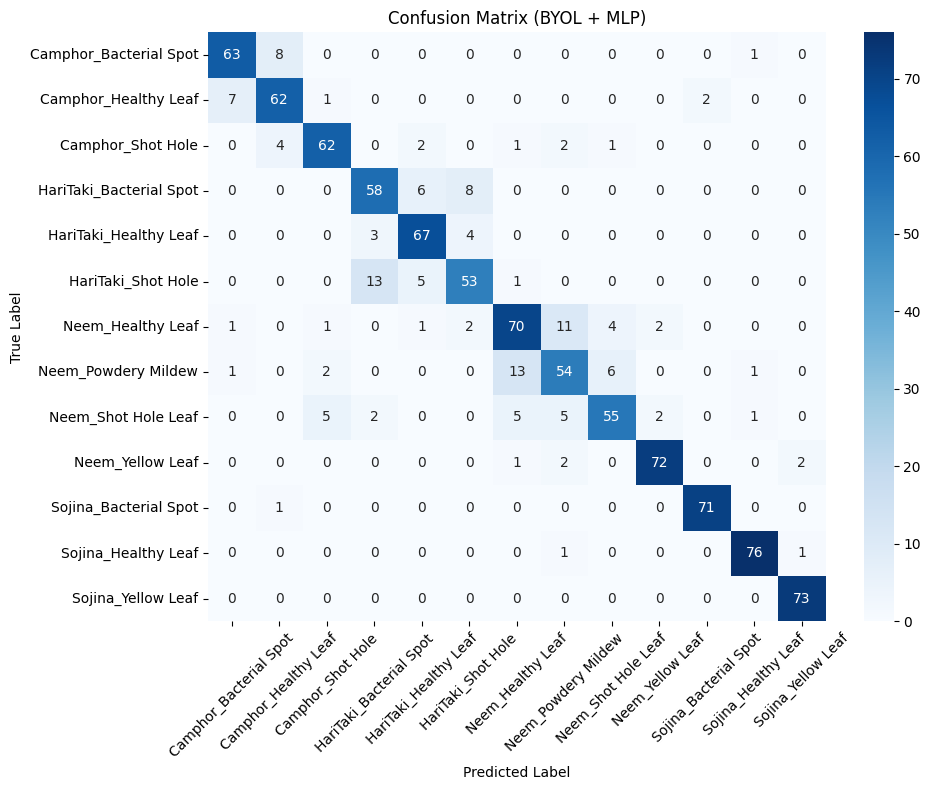

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(val_y, preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_labels,
            yticklabels=all_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (BYOL + MLP)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


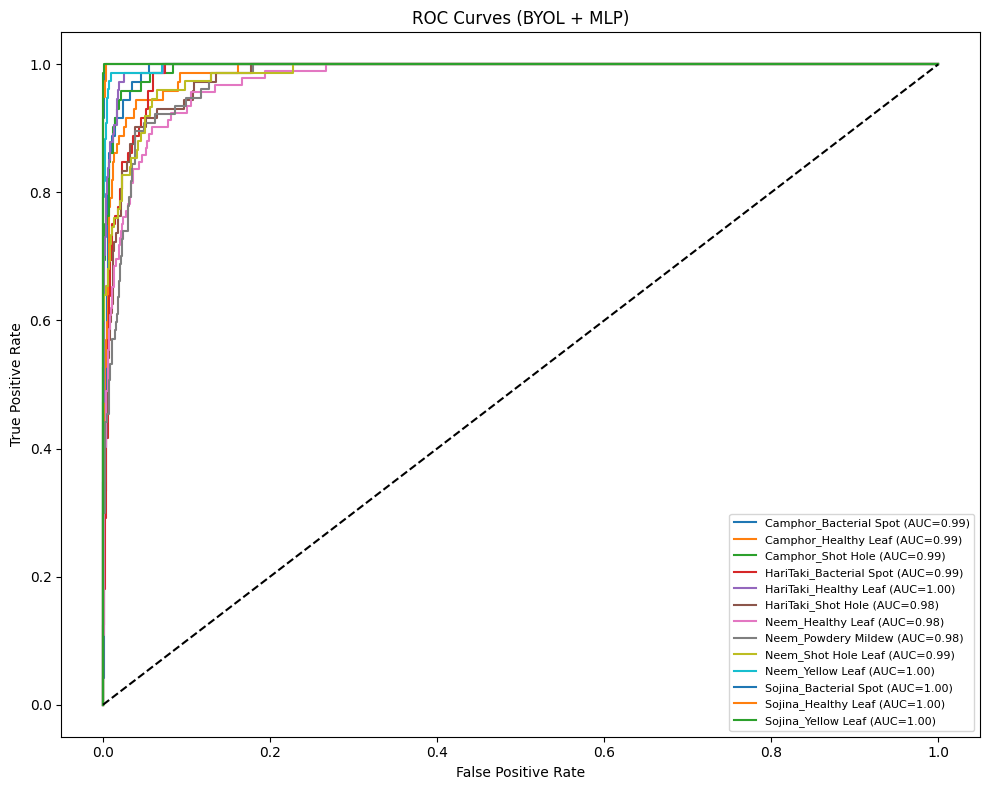

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

probs = mlp.predict_proba(val_X)
y_bin = label_binarize(val_y, classes=range(num_classes_plant))

plt.figure(figsize=(10,8))

for i, cls in enumerate(all_labels):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (BYOL + MLP)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
accuracies = []

n = train_X.shape[0]

for f in fractions:
    size = int(n * f)
    idx = np.random.choice(n, size, replace=False)

    mlp_sub = MLPClassifier(
        hidden_layer_sizes=(512,256),
        max_iter=1000,
        random_state=42
    )

    mlp_sub.fit(train_X[idx], train_y[idx])
    acc = accuracy_score(val_y, mlp_sub.predict(val_X))
    accuracies.append(acc)

    print(f"{f*100:.0f}% labels → Accuracy: {acc*100:.2f}%")


1% labels → Accuracy: 42.84%
5% labels → Accuracy: 64.42%
10% labels → Accuracy: 71.68%
25% labels → Accuracy: 76.79%
50% labels → Accuracy: 83.13%


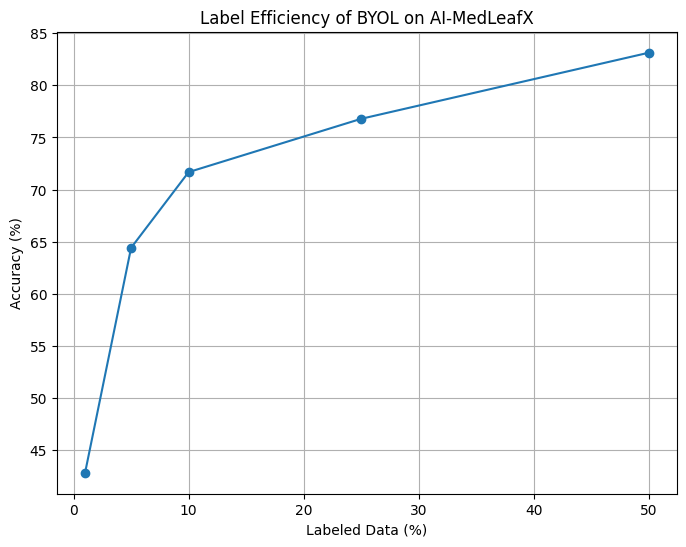

In [14]:
plt.figure(figsize=(8,6))
plt.plot([f*100 for f in fractions],
         [a*100 for a in accuracies],
         marker='o')

plt.xlabel("Labeled Data (%)")
plt.ylabel("Accuracy (%)")
plt.title("Label Efficiency of BYOL on AI-MedLeafX")
plt.grid(True)
plt.show()
